In [58]:
import os
import json
import shutil
import warnings
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error

# Google Drive
DRIVE_DIR = Path("/content/drive/MyDrive")

# Input files
INPUT_FILE = DRIVE_DIR / "model_ready_category_dataset.csv"
SPLIT_SCENARIOS_FILE = DRIVE_DIR / "time_split_scenarios.csv"
EXPERIMENT_CONFIG_FILE = DRIVE_DIR / "experiment_configuration.json"

# Model 2 output folder
MODEL_2_OUTPUT_DIR = DRIVE_DIR / "model_2_tree_based_outputs"

# Clean and recreate output folder
if MODEL_2_OUTPUT_DIR.exists():
    shutil.rmtree(MODEL_2_OUTPUT_DIR)

MODEL_2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Clean Model 2 output folder created at: {MODEL_2_OUTPUT_DIR}")

# Check input files
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not SPLIT_SCENARIOS_FILE.exists():
    raise FileNotFoundError(f"Split scenarios file not found: {SPLIT_SCENARIOS_FILE}")

if not EXPERIMENT_CONFIG_FILE.exists():
    raise FileNotFoundError(f"Experiment config file not found: {EXPERIMENT_CONFIG_FILE}")

print("All input files found.")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM is not available. Run: !pip install lightgbm -q")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. Run: !pip install xgboost -q")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False
    print("SHAP is not available. Run: !pip install shap -q")

Clean Model 2 output folder created at: /content/drive/MyDrive/model_2_tree_based_outputs
All input files found.


In [59]:
DRIVE_DIR = Path("/content/drive/MyDrive")

INPUT_FILE = DRIVE_DIR / "model_ready_category_dataset.csv"
SPLIT_SCENARIOS_FILE = DRIVE_DIR / "time_split_scenarios.csv"
MODEL_1_TEST_RESULTS_FILE = DRIVE_DIR / "model_1_statistical_baseline_outputs" / "model_1_test_results.csv"

MODEL_2_OUTPUT_DIR = DRIVE_DIR / "model_2_tree_based_outputs"
MODEL_2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_RESULTS_FILE = MODEL_2_OUTPUT_DIR / "model_2_validation_results.csv"
TEST_RESULTS_FILE = MODEL_2_OUTPUT_DIR / "model_2_test_results.csv"
BEST_CONFIG_FILE = MODEL_2_OUTPUT_DIR / "model_2_best_configurations.csv"
FORECASTS_FILE = MODEL_2_OUTPUT_DIR / "model_2_all_forecasts.csv"
MODEL_COMPARISON_FILE = MODEL_2_OUTPUT_DIR / "model_1_vs_model_2_comparison.csv"
EXPERIMENT_LOG_FILE = MODEL_2_OUTPUT_DIR / "model_2_experiment_log.json"

TARGET_COL = "weekly_quantity"
DATE_COL = "week_start"
CATEGORY_COL = "Product Category"

RANDOM_STATE = 42

LAG_FEATURES = [1, 2, 4, 8, 12, 26, 52]
ROLLING_WINDOWS = [4, 8, 12, 26]
OCCURRENCE_WINDOWS = [4, 8, 12]

TARGET_TRANSFORMATION_CANDIDATES = ["raw", "log1p"]

LIGHTGBM_BASE_GRID = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [15, 25, 40],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [1.0, 3.0, 5.0]
}

XGBOOST_BASE_GRID = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [3, 5, 10],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [1.0, 3.0, 5.0],
    "gamma": [0.0, 1.0]
}

MAX_CONFIGS_PER_MODEL_FAMILY = 12

NON_FEATURE_COLUMNS = [
    CATEGORY_COL,
    DATE_COL,
    TARGET_COL,
    "weekly_revenue",
    "transaction_count",
    "unique_skus",
    "unique_customers",
    "demand_positive"
]

In [60]:
def build_full_grid(param_grid):
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    rows = []
    for combination in product(*values):
        rows.append(dict(zip(keys, combination)))
    return rows


def sample_configurations(configs, n, random_state=42):
    rng = np.random.default_rng(random_state)
    if len(configs) <= n:
        return configs
    indices = rng.choice(len(configs), size=n, replace=False)
    return [configs[i] for i in indices]


def build_candidate_configs():
    candidate_configs = []

    if LIGHTGBM_AVAILABLE:
        lgbm_grid = build_full_grid(LIGHTGBM_BASE_GRID)
        lgbm_sampled = sample_configurations(
            lgbm_grid,
            MAX_CONFIGS_PER_MODEL_FAMILY,
            random_state=RANDOM_STATE
        )
        for i, params in enumerate(lgbm_sampled):
            for target_transformation in TARGET_TRANSFORMATION_CANDIDATES:
                config = {
                    "model_family": "LightGBM",
                    "config_id": f"lgbm_{i:03d}_{target_transformation}",
                    "target_transformation": target_transformation,
                    **params,
                    "random_state": RANDOM_STATE
                }
                candidate_configs.append(config)

    if XGBOOST_AVAILABLE:
        xgb_grid = build_full_grid(XGBOOST_BASE_GRID)
        xgb_sampled = sample_configurations(
            xgb_grid,
            MAX_CONFIGS_PER_MODEL_FAMILY,
            random_state=RANDOM_STATE + 1
        )
        for i, params in enumerate(xgb_sampled):
            for target_transformation in TARGET_TRANSFORMATION_CANDIDATES:
                config = {
                    "model_family": "XGBoost",
                    "config_id": f"xgb_{i:03d}_{target_transformation}",
                    "target_transformation": target_transformation,
                    **params,
                    "objective": "reg:squarederror",
                    "random_state": RANDOM_STATE
                }
                candidate_configs.append(config)

    return candidate_configs


CANDIDATE_CONFIGS = build_candidate_configs()

if not CANDIDATE_CONFIGS:
    raise ImportError("Neither LightGBM nor XGBoost is available. Install at least one model library.")

experiment_log = {
    "run_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "Model 2 - Global Tree-Based Forecasting Final No-Leakage Version",
    "forecasting_strategy": "Recursive multi-step forecasting",
    "input_file": str(INPUT_FILE),
    "split_scenarios_file": str(SPLIT_SCENARIOS_FILE),
    "target_transformation_candidates": TARGET_TRANSFORMATION_CANDIDATES,
    "lightgbm_grid": LIGHTGBM_BASE_GRID if LIGHTGBM_AVAILABLE else None,
    "xgboost_grid": XGBOOST_BASE_GRID if XGBOOST_AVAILABLE else None,
    "max_configs_per_model_family": MAX_CONFIGS_PER_MODEL_FAMILY,
    "candidate_configs_tested": CANDIDATE_CONFIGS,
    "selection_rule": "Lowest validation MASE; RMSE, MAE, and sMAPE are used as tie-breakers.",
    "leakage_control": "Current-period demand occurrence is excluded. All temporal and occurrence features are lagged or recursively updated.",
    "excluded_target_derived_features": ["demand_positive"],
    "explainability": "SHAP analysis is applied to the selected tree-based model."
}

with open(EXPERIMENT_LOG_FILE, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print("Total candidate configurations:", len(CANDIDATE_CONFIGS))

Total candidate configurations: 48


In [61]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not SPLIT_SCENARIOS_FILE.exists():
    raise FileNotFoundError(f"Split scenarios file not found: {SPLIT_SCENARIOS_FILE}")

category_df = pd.read_csv(INPUT_FILE)
split_scenarios = pd.read_csv(SPLIT_SCENARIOS_FILE)

category_df[DATE_COL] = pd.to_datetime(category_df[DATE_COL])
category_df = category_df.sort_values([CATEGORY_COL, DATE_COL]).reset_index(drop=True)

print("Model-ready category dataset loaded.")
print("Shape:", category_df.shape)
print("Date range:", category_df[DATE_COL].min(), "to", category_df[DATE_COL].max())
print("Categories:", category_df[CATEGORY_COL].nunique())
print("Total demand:", category_df[TARGET_COL].sum())

Model-ready category dataset loaded.
Shape: (6200, 44)
Date range: 2023-01-09 00:00:00 to 2025-12-22 00:00:00
Categories: 40
Total demand: 530935.0


In [62]:
category_df = category_df.sort_values([CATEGORY_COL, DATE_COL]).copy()
category_df["demand_positive"] = (category_df[TARGET_COL] > 0).astype(int)

category_df["lag_1_demand_positive"] = (
    category_df.groupby(CATEGORY_COL)["demand_positive"].shift(1).fillna(0).astype(int)
)
category_df["lag_2_demand_positive"] = (
    category_df.groupby(CATEGORY_COL)["demand_positive"].shift(2).fillna(0).astype(int)
)

category_df["lag_1_zero"] = 1 - category_df["lag_1_demand_positive"]
category_df["lag_2_zero"] = 1 - category_df["lag_2_demand_positive"]

for window in OCCURRENCE_WINDOWS:
    shifted_positive = category_df.groupby(CATEGORY_COL)["demand_positive"].shift(1)
    category_df[f"recent_positive_ratio_{window}"] = (
        shifted_positive
        .groupby(category_df[CATEGORY_COL])
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )
    category_df[f"recent_zero_ratio_{window}"] = 1 - category_df[f"recent_positive_ratio_{window}"]

def calculate_zero_streak_from_history(series):
    shifted = series.shift(1).fillna(0).values
    streaks = []
    current_streak = 0
    for value in shifted:
        if value == 0:
            current_streak += 1
        else:
            current_streak = 0
        streaks.append(current_streak)
    return pd.Series(streaks, index=series.index)

category_df["zero_streak"] = (
    category_df
    .groupby(CATEGORY_COL)[TARGET_COL]
    .transform(calculate_zero_streak_from_history)
)

category_df = category_df.fillna(0)

In [63]:
category_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
category_df["category_encoded"] = category_encoder.fit_transform(category_df[[CATEGORY_COL]])

split_columns = [col for col in category_df.columns if col.startswith("split_")]

feature_columns = [
    col for col in category_df.columns
    if col not in NON_FEATURE_COLUMNS
    and col not in split_columns
]
feature_columns = [col for col in feature_columns if col != TARGET_COL]

for forbidden_feature in ["demand_positive", TARGET_COL]:
    if forbidden_feature in feature_columns:
        raise ValueError(f"Leakage feature detected in feature_columns: {forbidden_feature}")

missing_feature_values = category_df[feature_columns].isna().sum().sum()
if missing_feature_values > 0:
    category_df[feature_columns] = category_df[feature_columns].fillna(0)

print("\nFeature columns used in Model 2:")
print(feature_columns)
print("Number of features:", len(feature_columns))

feature_list_file = MODEL_2_OUTPUT_DIR / "model_2_feature_columns.csv"
pd.DataFrame({"feature": feature_columns}).to_csv(feature_list_file, index=False, encoding="utf-8-sig")


Feature columns used in Model 2:
['avg_unit_price', 'avg_gross_margin_pct', 'negative_margin_share', 'from_china_share', 'from_india_share', 'year', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_1_demand_positive', 'lag_2_demand_positive', 'lag_1_zero', 'lag_2_zero', 'recent_positive_ratio_4', 'recent_zero_ratio_4', 'recent_positive_ratio_8', 'recent_zero_ratio_8', 'recent_positive_ratio_12', 'recent_zero_ratio_12', 'zero_streak', 'category_encoded']
Number of features: 40


In [64]:
def root_mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    return np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100

def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) <= seasonality:
        return np.nan

    naive_errors = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    scale = np.mean(naive_errors)

    if scale == 0 or np.isnan(scale):
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(y_true, y_pred, y_train, seasonality=1):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train, seasonality=seasonality)
    }

In [65]:
def transform_target(y, transformation):
    y = np.asarray(y, dtype=float)
    if transformation == "raw":
        return y
    if transformation == "log1p":
        return np.log1p(np.maximum(y, 0))
    raise ValueError(f"Unknown target transformation: {transformation}")

def inverse_transform_prediction(y_pred, transformation):
    y_pred = np.asarray(y_pred, dtype=float)
    if transformation == "raw":
        return y_pred
    if transformation == "log1p":
        return np.expm1(y_pred)
    raise ValueError(f"Unknown target transformation: {transformation}")

def make_non_negative(y_pred):
    return np.maximum(np.asarray(y_pred, dtype=float), 0)

def create_model(config):
    model_family = config["model_family"]
    excluded_keys = ["model_family", "config_id", "target_transformation"]
    params = {k: v for k, v in config.items() if k not in excluded_keys}

    if model_family == "LightGBM":
        return lgb.LGBMRegressor(
            **params,
            verbose=-1,
            n_jobs=-1
        )

    if model_family == "XGBoost":
        return xgb.XGBRegressor(
            **params,
            n_jobs=-1
        )

    raise ValueError(f"Unknown model family: {model_family}")

def select_best_configuration(results_df):
    temp = results_df.copy().replace([np.inf, -np.inf], np.nan)
    if temp["MASE"].notna().any():
        sort_cols = ["MASE", "RMSE", "MAE", "sMAPE"]
    else:
        sort_cols = ["RMSE", "MAE", "sMAPE"]
    return temp.sort_values(sort_cols, ascending=True).iloc[0]

In [66]:
def calculate_current_zero_streak(history_values):
    streak = 0
    for value in history_values[::-1]:
        if value == 0:
            streak += 1
        else:
            break
    return streak

def update_recursive_features(history_df, next_row):
    history_values = history_df[TARGET_COL].astype(float).values
    positive_history = (history_values > 0).astype(int)

    for lag in LAG_FEATURES:
        feature_name = f"lag_{lag}"
        if feature_name in next_row.index:
            next_row[feature_name] = history_values[-lag] if len(history_values) >= lag else 0

    for window in ROLLING_WINDOWS:
        mean_feature = f"rolling_mean_{window}"
        std_feature = f"rolling_std_{window}"
        effective_window = min(window, len(history_values))
        recent_values = history_values[-effective_window:] if effective_window > 0 else np.array([0.0])

        if mean_feature in next_row.index:
            next_row[mean_feature] = np.mean(recent_values)

        if std_feature in next_row.index:
            next_row[std_feature] = np.std(recent_values, ddof=1) if len(recent_values) >= 2 else 0

    if "lag_1_demand_positive" in next_row.index:
        next_row["lag_1_demand_positive"] = positive_history[-1] if len(positive_history) >= 1 else 0

    if "lag_2_demand_positive" in next_row.index:
        next_row["lag_2_demand_positive"] = positive_history[-2] if len(positive_history) >= 2 else 0

    if "lag_1_zero" in next_row.index:
        next_row["lag_1_zero"] = 1 - next_row.get("lag_1_demand_positive", 0)

    if "lag_2_zero" in next_row.index:
        next_row["lag_2_zero"] = 1 - next_row.get("lag_2_demand_positive", 0)

    for window in OCCURRENCE_WINDOWS:
        effective_window = min(window, len(positive_history))
        recent_positive = positive_history[-effective_window:] if effective_window > 0 else np.array([0])

        positive_ratio_feature = f"recent_positive_ratio_{window}"
        zero_ratio_feature = f"recent_zero_ratio_{window}"

        if positive_ratio_feature in next_row.index:
            next_row[positive_ratio_feature] = np.mean(recent_positive)

        if zero_ratio_feature in next_row.index:
            next_row[zero_ratio_feature] = 1 - np.mean(recent_positive)

    if "zero_streak" in next_row.index:
        next_row["zero_streak"] = calculate_current_zero_streak(history_values)

    return next_row

def recursive_forecast(model, history_df, future_df, feature_cols, target_transformation):
    all_predictions = []

    for category in sorted(future_df[CATEGORY_COL].unique()):
        cat_history = history_df[history_df[CATEGORY_COL] == category].copy()
        cat_future = future_df[future_df[CATEGORY_COL] == category].copy().sort_values(DATE_COL)

        working_history = cat_history[[DATE_COL, CATEGORY_COL, TARGET_COL]].copy()

        for _, row in cat_future.iterrows():
            updated_row = update_recursive_features(working_history, row.copy())
            X_next = pd.DataFrame([updated_row[feature_cols].astype(float).values], columns=feature_cols)
            y_pred_transformed = model.predict(X_next)[0]
            y_hat = inverse_transform_prediction([y_pred_transformed], target_transformation)[0]
            y_hat = float(make_non_negative([y_hat])[0])

            all_predictions.append({
                CATEGORY_COL: category,
                DATE_COL: updated_row[DATE_COL],
                "y_true": updated_row[TARGET_COL],
                "y_pred": y_hat
            })

            new_history_row = pd.DataFrame({
                DATE_COL: [updated_row[DATE_COL]],
                CATEGORY_COL: [category],
                TARGET_COL: [y_hat]
            })
            working_history = pd.concat([working_history, new_history_row], ignore_index=True)

    return pd.DataFrame(all_predictions)

In [67]:
all_validation_results = []
all_test_results = []
all_forecasts = []
best_configurations = []
trained_selected_models = {}

for _, split_row in split_scenarios.iterrows():
    scenario_id = split_row["scenario_id"]
    split_column = f"split_{scenario_id}"

    if split_column not in category_df.columns:
        raise ValueError(f"Split column not found: {split_column}")

    print(f"Running Model 2 split scenario: {scenario_id}")

    train_df = category_df[category_df[split_column] == "train"].copy()
    validation_df = category_df[category_df[split_column] == "validation"].copy()
    test_df = category_df[category_df[split_column] == "test"].copy()

    if train_df.empty or validation_df.empty or test_df.empty:
        print(f"Skipping scenario {scenario_id}: empty split.")
        continue

    X_train = train_df[feature_columns].astype(float)
    y_train_raw = train_df[TARGET_COL].astype(float).values

    scenario_validation_results = []

    for config in CANDIDATE_CONFIGS:
        config_id = config["config_id"]
        model_family = config["model_family"]
        target_transformation = config["target_transformation"]

        print(f"Training {model_family} | {config_id} | Scenario {scenario_id}")

        try:
            y_train_model = transform_target(y_train_raw, target_transformation)
            model = create_model(config)
            model.fit(X_train, y_train_model)

            validation_forecasts = recursive_forecast(
                model=model,
                history_df=train_df,
                future_df=validation_df,
                feature_cols=feature_columns,
                target_transformation=target_transformation
            )

            merged_validation = validation_df[[CATEGORY_COL, DATE_COL, TARGET_COL]].merge(
                validation_forecasts[[CATEGORY_COL, DATE_COL, "y_pred"]],
                on=[CATEGORY_COL, DATE_COL],
                how="left"
            )

            if merged_validation["y_pred"].isna().any():
                raise ValueError("Missing validation predictions detected.")

            metrics = evaluate_forecast(
                y_true=merged_validation[TARGET_COL].values,
                y_pred=merged_validation["y_pred"].values,
                y_train=y_train_raw,
                seasonality=1
            )

            result = {
                "scenario_id": scenario_id,
                "model_family": model_family,
                "config_id": config_id,
                "target_transformation": target_transformation,
                "config": json.dumps(config),
                **metrics
            }
            scenario_validation_results.append(result)
            all_validation_results.append(result)

        except Exception as e:
            result = {
                "scenario_id": scenario_id,
                "model_family": model_family,
                "config_id": config_id,
                "target_transformation": target_transformation,
                "config": json.dumps(config),
                "MAE": np.nan,
                "RMSE": np.nan,
                "sMAPE": np.nan,
                "MASE": np.nan,
                "error": str(e)
            }
            scenario_validation_results.append(result)
            all_validation_results.append(result)
            print(f"Failed: {config_id} | Error: {e}")

        pd.DataFrame(all_validation_results).to_csv(VALIDATION_RESULTS_FILE, index=False, encoding="utf-8-sig")

    scenario_validation_df = pd.DataFrame(scenario_validation_results)
    scenario_validation_df_success = scenario_validation_df.dropna(subset=["RMSE"])

    if scenario_validation_df_success.empty:
        print(f"No successful configurations for scenario {scenario_id}.")
        continue

    best_row = select_best_configuration(scenario_validation_df_success)
    best_config = json.loads(best_row["config"])
    best_configurations.append(best_row.to_dict())

    print("\nBest configuration for scenario:")
    print(best_row)

    train_validation_df = pd.concat([train_df, validation_df], axis=0).sort_values([CATEGORY_COL, DATE_COL])
    X_train_validation = train_validation_df[feature_columns].astype(float)
    y_train_validation_raw = train_validation_df[TARGET_COL].astype(float).values
    y_train_validation_model = transform_target(
        y_train_validation_raw,
        best_config["target_transformation"]
    )

    selected_model = create_model(best_config)
    selected_model.fit(X_train_validation, y_train_validation_model)
    trained_selected_models[scenario_id] = {
        "model": selected_model,
        "config": best_config
    }

    test_forecasts = recursive_forecast(
        model=selected_model,
        history_df=train_validation_df,
        future_df=test_df,
        feature_cols=feature_columns,
        target_transformation=best_config["target_transformation"]
    )

    merged_test = test_df[[CATEGORY_COL, DATE_COL, TARGET_COL]].merge(
        test_forecasts[[CATEGORY_COL, DATE_COL, "y_pred"]],
        on=[CATEGORY_COL, DATE_COL],
        how="left"
    )

    if merged_test["y_pred"].isna().any():
        raise ValueError(f"Missing test predictions for scenario {scenario_id}.")

    test_metrics = evaluate_forecast(
        y_true=merged_test[TARGET_COL].values,
        y_pred=merged_test["y_pred"].values,
        y_train=y_train_validation_raw,
        seasonality=1
    )

    test_result = {
        "scenario_id": scenario_id,
        "selected_model_family": best_config["model_family"],
        "selected_config_id": best_config["config_id"],
        "target_transformation": best_config["target_transformation"],
        "selected_config": json.dumps(best_config),
        **test_metrics
    }
    all_test_results.append(test_result)

    forecast_output = merged_test.copy()
    forecast_output["scenario_id"] = scenario_id
    forecast_output["selected_model_family"] = best_config["model_family"]
    forecast_output["selected_config_id"] = best_config["config_id"]
    forecast_output["target_transformation"] = best_config["target_transformation"]
    forecast_output = forecast_output.rename(columns={TARGET_COL: "y_true"})
    forecast_output["absolute_error"] = np.abs(forecast_output["y_true"] - forecast_output["y_pred"])
    all_forecasts.append(forecast_output)

    pd.DataFrame(all_test_results).to_csv(TEST_RESULTS_FILE, index=False, encoding="utf-8-sig")
    pd.DataFrame(best_configurations).to_csv(BEST_CONFIG_FILE, index=False, encoding="utf-8-sig")
    pd.concat(all_forecasts, ignore_index=True).to_csv(FORECASTS_FILE, index=False, encoding="utf-8-sig")

    print(
        f"Scenario: {scenario_id} | Selected: {best_config['model_family']} / {best_config['config_id']} | "
        f"Target: {best_config['target_transformation']} | "
        f"Test MAE: {test_metrics['MAE']:.3f} | RMSE: {test_metrics['RMSE']:.3f} | MASE: {test_metrics['MASE']:.3f}"
    )

Running Model 2 split scenario: val_4_test_4
Training LightGBM | lgbm_000_raw | Scenario val_4_test_4
Training LightGBM | lgbm_000_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_001_raw | Scenario val_4_test_4
Training LightGBM | lgbm_001_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_002_raw | Scenario val_4_test_4
Training LightGBM | lgbm_002_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_003_raw | Scenario val_4_test_4
Training LightGBM | lgbm_003_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_004_raw | Scenario val_4_test_4
Training LightGBM | lgbm_004_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_005_raw | Scenario val_4_test_4
Training LightGBM | lgbm_005_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_006_raw | Scenario val_4_test_4
Training LightGBM | lgbm_006_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_007_raw | Scenario val_4_test_4
Training LightGBM | lgbm_007_log1p | Scenario val_4_test_4
Training LightGBM | lgbm_00

In [68]:
validation_results_df = pd.DataFrame(all_validation_results)
test_results_df = pd.DataFrame(all_test_results)
best_configurations_df = pd.DataFrame(best_configurations)
forecasts_df = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()

validation_results_df.to_csv(VALIDATION_RESULTS_FILE, index=False, encoding="utf-8-sig")
test_results_df.to_csv(TEST_RESULTS_FILE, index=False, encoding="utf-8-sig")
best_configurations_df.to_csv(BEST_CONFIG_FILE, index=False, encoding="utf-8-sig")
forecasts_df.to_csv(FORECASTS_FILE, index=False, encoding="utf-8-sig")

print("\nModel 2 final no-leakage experiment completed.")
print("Validation results:", validation_results_df.shape)
print("Test results:", test_results_df.shape)
print("Forecasts:", forecasts_df.shape)

validation_summary = (
    validation_results_df
    .dropna(subset=["RMSE"])
    .groupby(["scenario_id", "model_family", "target_transformation"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MASE=("MASE", "mean"),
        successful_configs=("config_id", "count")
    )
    .sort_values(["scenario_id", "mean_MASE", "mean_RMSE"])
)

validation_summary_file = MODEL_2_OUTPUT_DIR / "model_2_validation_summary_by_family.csv"
validation_summary.to_csv(validation_summary_file, index=False, encoding="utf-8-sig")

print("\nValidation summary:")
print(validation_summary)


Model 2 final no-leakage experiment completed.
Validation results: (432, 9)
Test results: (9, 9)
Forecasts: (2880, 9)

Validation summary:
       scenario_id model_family target_transformation    mean_MAE   mean_RMSE  mean_sMAPE  mean_MASE  successful_configs
3   val_12_test_12      XGBoost                   raw   63.224560  220.013117  137.895026   1.175633                  12
1   val_12_test_12     LightGBM                   raw   68.327930  252.217966  141.897662   1.270528                  12
2   val_12_test_12      XGBoost                 log1p   82.348447  337.036370  158.221259   1.531234                  12
0   val_12_test_12     LightGBM                 log1p   87.350596  369.127910  159.614378   1.624246                  12
6    val_12_test_4      XGBoost                 log1p   65.002266  230.686016  137.117529   1.224347                  12
4    val_12_test_4     LightGBM                 log1p   66.914091  253.670156  138.096518   1.260357                  12
5    val_12_t

In [69]:
test_summary = (
    test_results_df
    .groupby(["selected_model_family", "target_transformation"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MASE=("MASE", "mean"),
        scenarios=("scenario_id", "count")
    )
    .sort_values(["mean_MASE", "mean_RMSE"])
)

test_summary_file = MODEL_2_OUTPUT_DIR / "model_2_test_summary_selected_models.csv"
test_summary.to_csv(test_summary_file, index=False, encoding="utf-8-sig")

print("\nTest summary:")
print(test_summary)

selected_config_counts = (
    best_configurations_df
    .groupby(["model_family", "config_id", "target_transformation"], as_index=False)
    .agg(selected_count=("scenario_id", "count"))
    .sort_values("selected_count", ascending=False)
)

selected_config_counts_file = MODEL_2_OUTPUT_DIR / "model_2_selected_config_counts.csv"
selected_config_counts.to_csv(selected_config_counts_file, index=False, encoding="utf-8-sig")

print("\nSelected configuration counts:")
print(selected_config_counts)


Test summary:
  selected_model_family target_transformation   mean_MAE   mean_RMSE  mean_sMAPE  mean_MASE  scenarios
0              LightGBM                 log1p  10.455815   30.925049  146.678178   0.193354          3
2               XGBoost                 log1p  11.432698   33.354307  158.195900   0.210868          2
3               XGBoost                   raw  39.365708   84.337578  126.481801   0.713849          2
1              LightGBM                   raw  67.643572  185.836710  147.355877   1.219885          2

Selected configuration counts:
  model_family       config_id target_transformation  selected_count
7      XGBoost   xgb_008_log1p                 log1p               2
0     LightGBM    lgbm_000_raw                   raw               1
2     LightGBM  lgbm_005_log1p                 log1p               1
1     LightGBM  lgbm_002_log1p                 log1p               1
3     LightGBM  lgbm_008_log1p                 log1p               1
4     LightGBM    lgbm_0

In [70]:
if MODEL_1_TEST_RESULTS_FILE.exists():
    model_1_test = pd.read_csv(MODEL_1_TEST_RESULTS_FILE)

    model_1_summary = (
        model_1_test
        .groupby("scenario_id", as_index=False)
        .agg(
            model_1_MAE=("MAE", "mean"),
            model_1_RMSE=("RMSE", "mean"),
            model_1_sMAPE=("sMAPE", "mean"),
            model_1_MASE=("MASE", "mean")
        )
    )

    model_2_summary = (
        test_results_df
        .groupby("scenario_id", as_index=False)
        .agg(
            model_2_MAE=("MAE", "mean"),
            model_2_RMSE=("RMSE", "mean"),
            model_2_sMAPE=("sMAPE", "mean"),
            model_2_MASE=("MASE", "mean")
        )
    )

    model_comparison = model_1_summary.merge(model_2_summary, on="scenario_id", how="inner")
    model_comparison["MASE_improvement_pct"] = (
        (model_comparison["model_1_MASE"] - model_comparison["model_2_MASE"]) /
        model_comparison["model_1_MASE"]
    ) * 100
    model_comparison["RMSE_improvement_pct"] = (
        (model_comparison["model_1_RMSE"] - model_comparison["model_2_RMSE"]) /
        model_comparison["model_1_RMSE"]
    ) * 100

    model_comparison.to_csv(MODEL_COMPARISON_FILE, index=False, encoding="utf-8-sig")

    print("\nModel 1 vs Model 2 comparison:")
    print(model_comparison)
else:
    model_comparison = pd.DataFrame()
    print("Model 1 test results not found. Skipping comparison.")


Model 1 vs Model 2 comparison:
      scenario_id  model_1_MAE  model_1_RMSE  model_1_sMAPE  model_1_MASE  model_2_MAE  model_2_RMSE  model_2_sMAPE  model_2_MASE  MASE_improvement_pct  RMSE_improvement_pct
0  val_12_test_12    60.858989     73.680509      86.063294      1.283446    85.064780    268.255314     140.756864      1.534059            -19.526594           -264.079072
1   val_12_test_4    12.554074     17.694430      84.072744      0.227976     8.943196     28.849112     159.510908      0.166748             26.856965            -63.040647
2   val_12_test_8    35.601802     43.341612     101.543849      0.536160    27.938208     62.093027     123.927394      0.511693              4.563482            -43.264231
3   val_4_test_12    55.728052     69.140620      81.387296      1.036065    50.222363    103.418107     153.954890      0.905711             12.581678            -49.576481
4    val_4_test_4    13.526078     18.100070      83.981431      0.231412     8.336205     25.9599

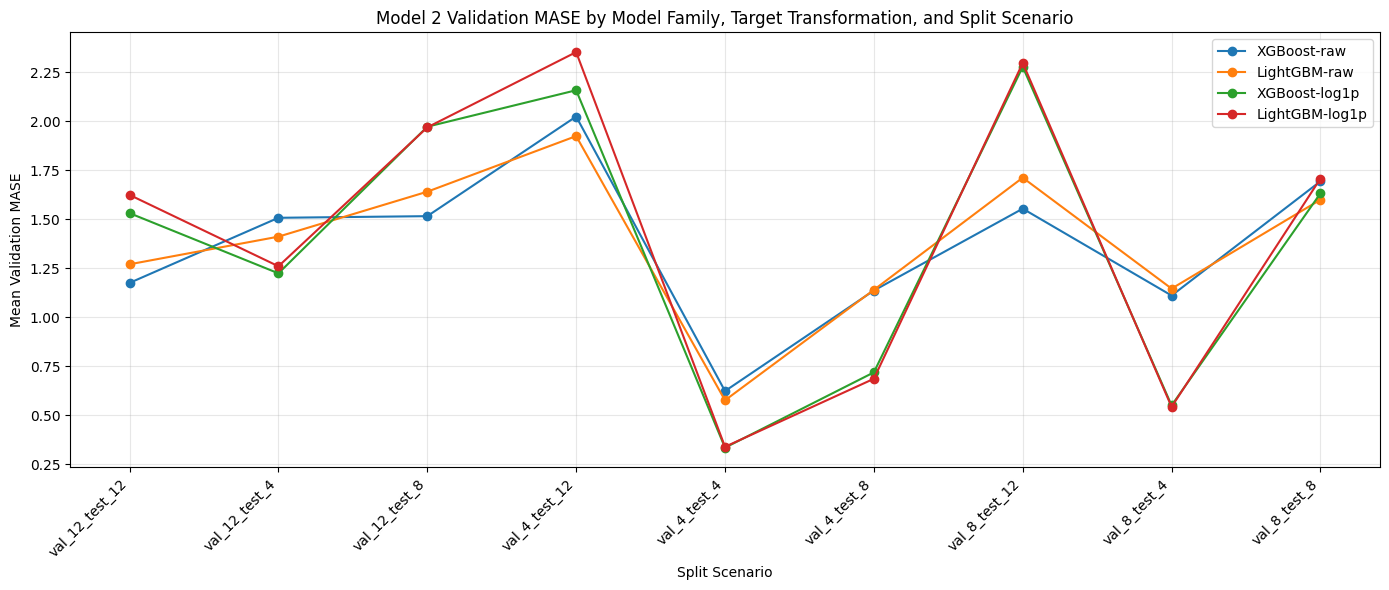

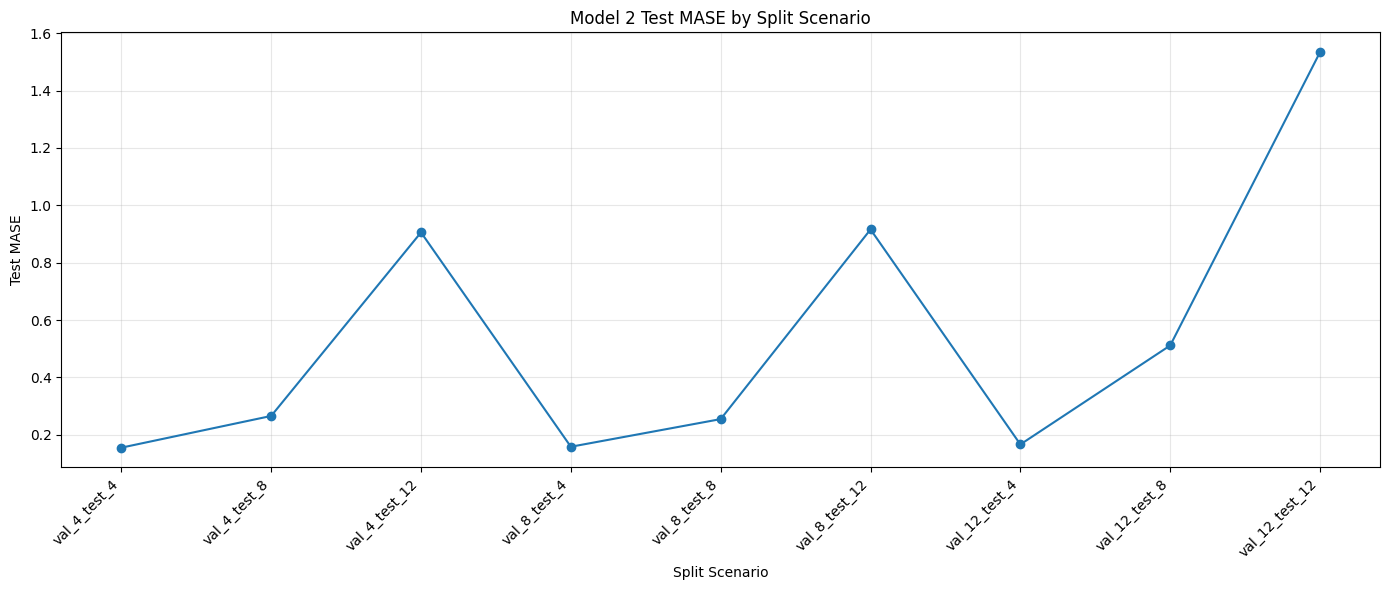

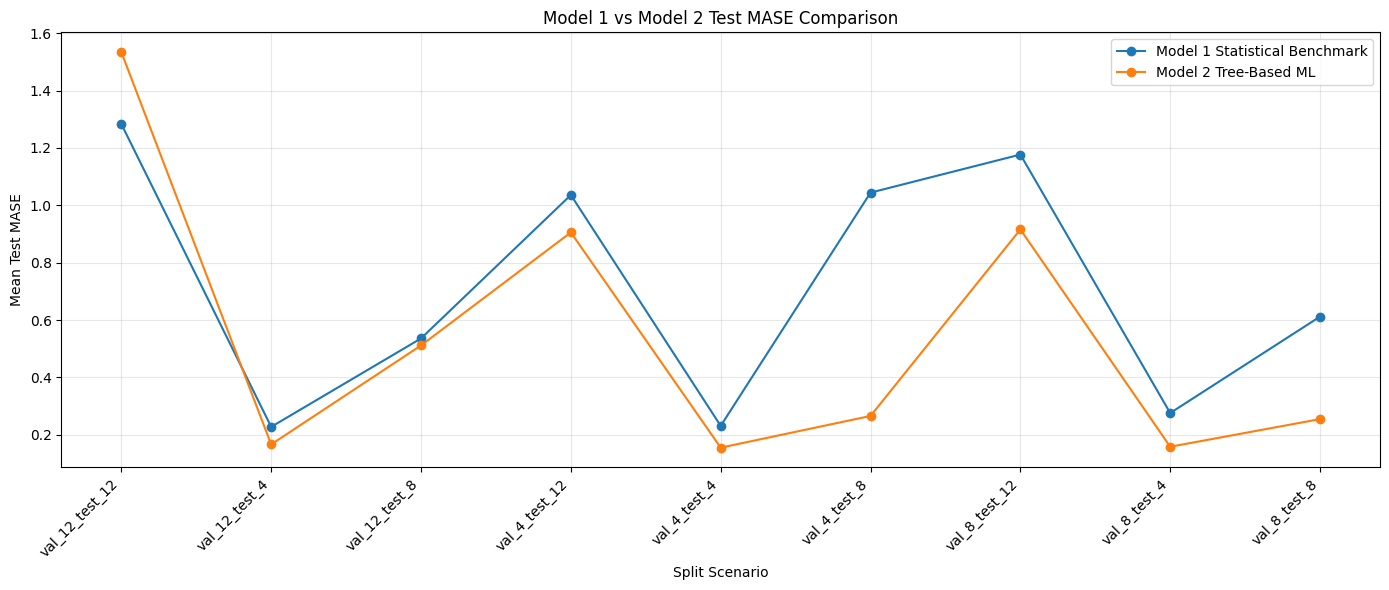

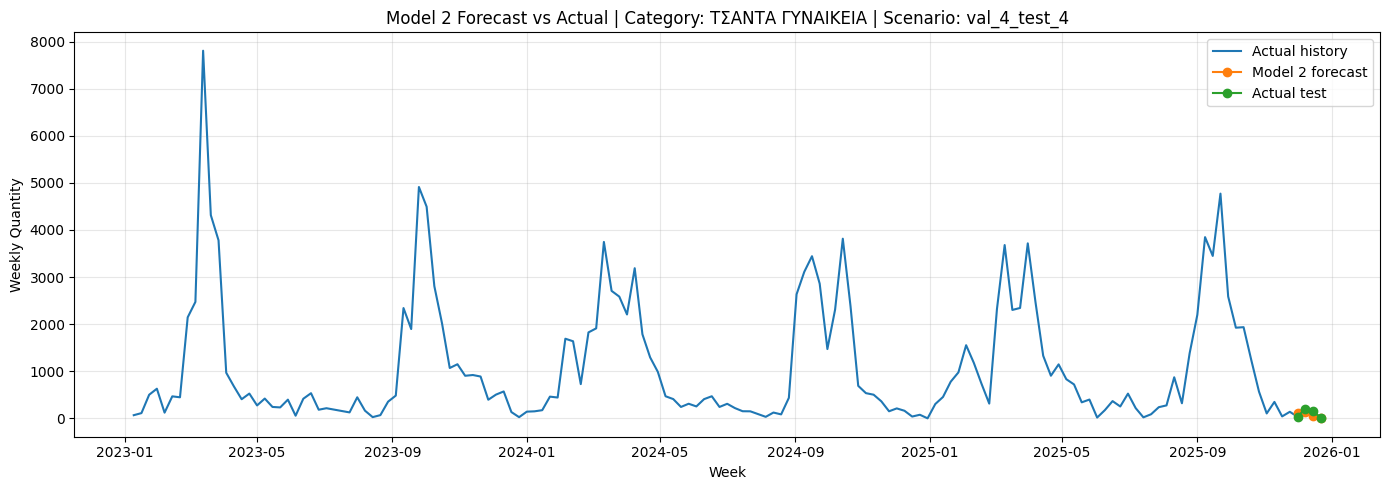

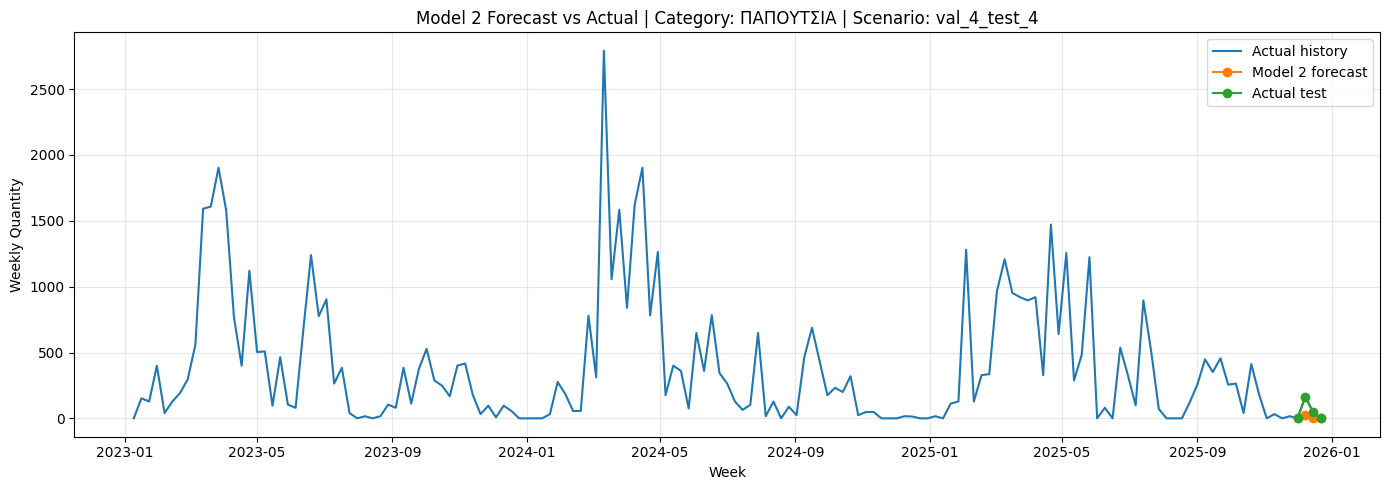

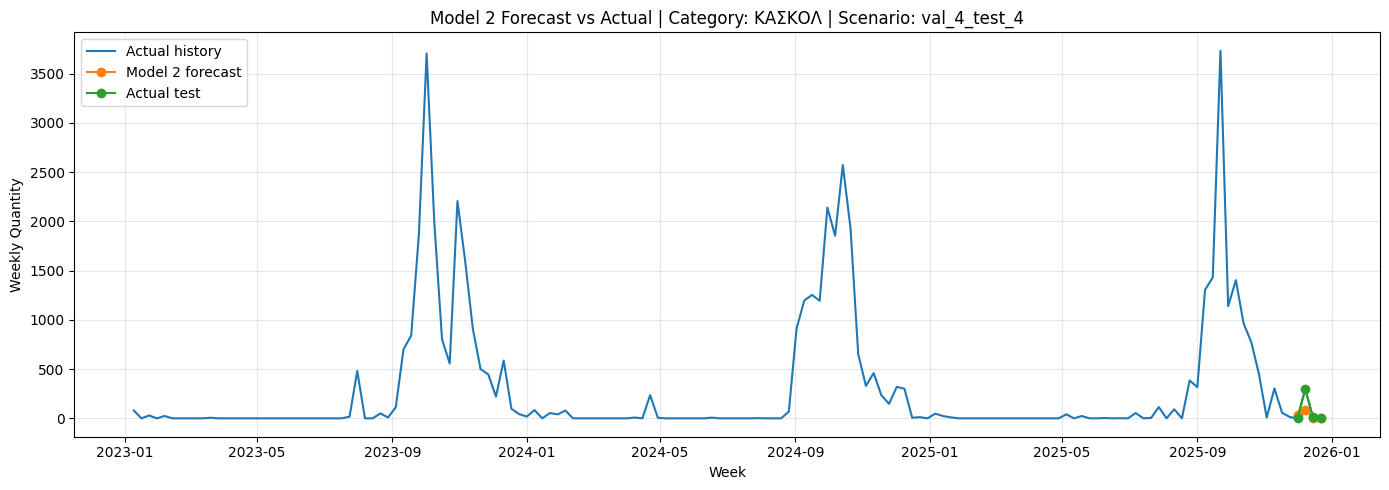

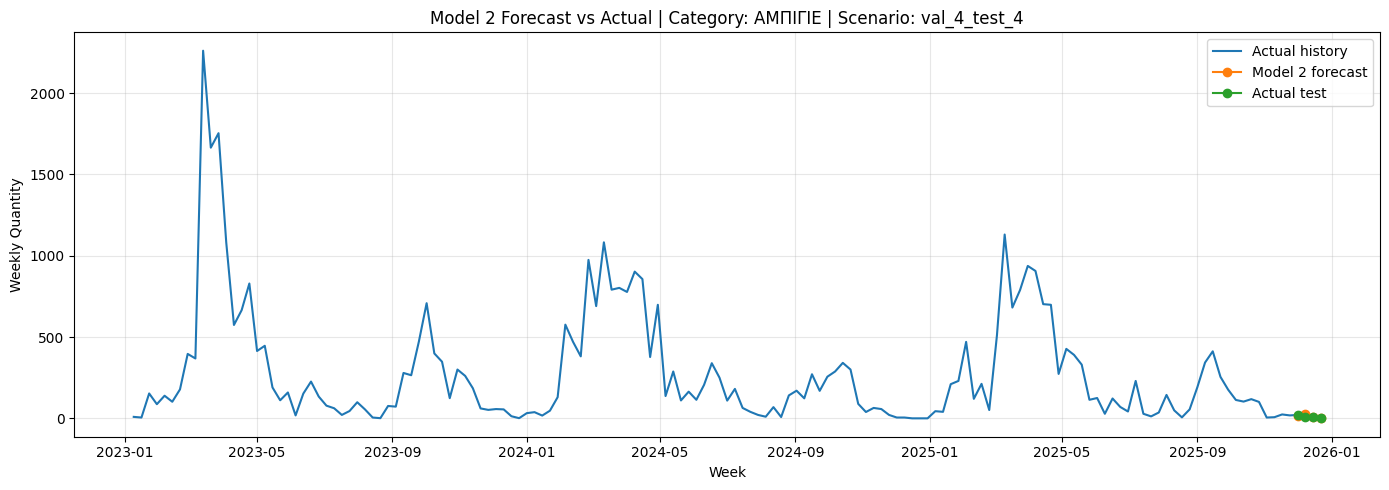

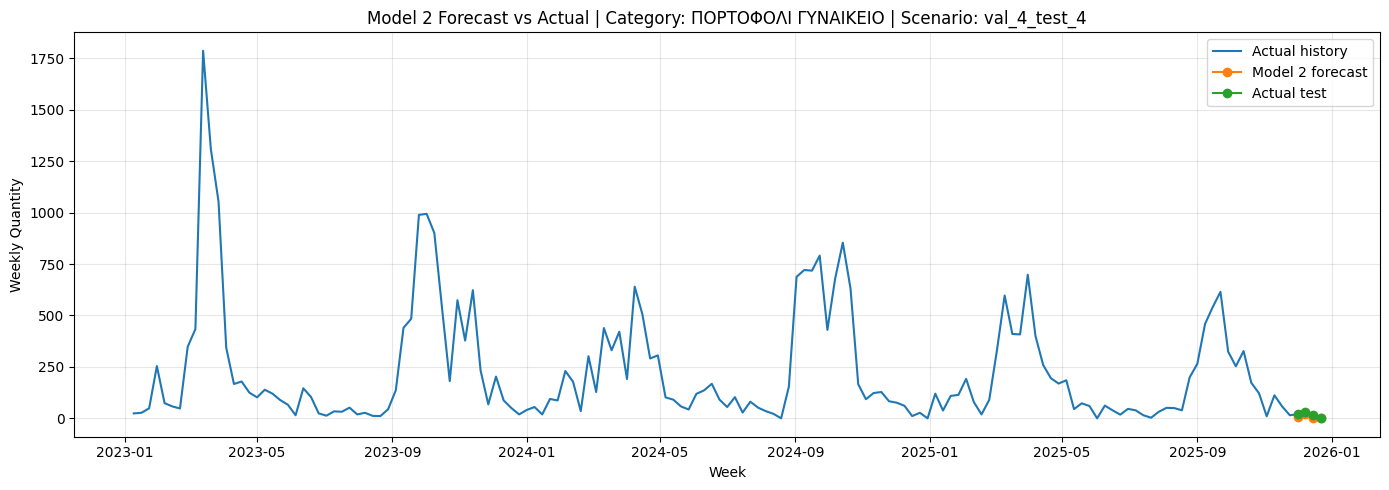

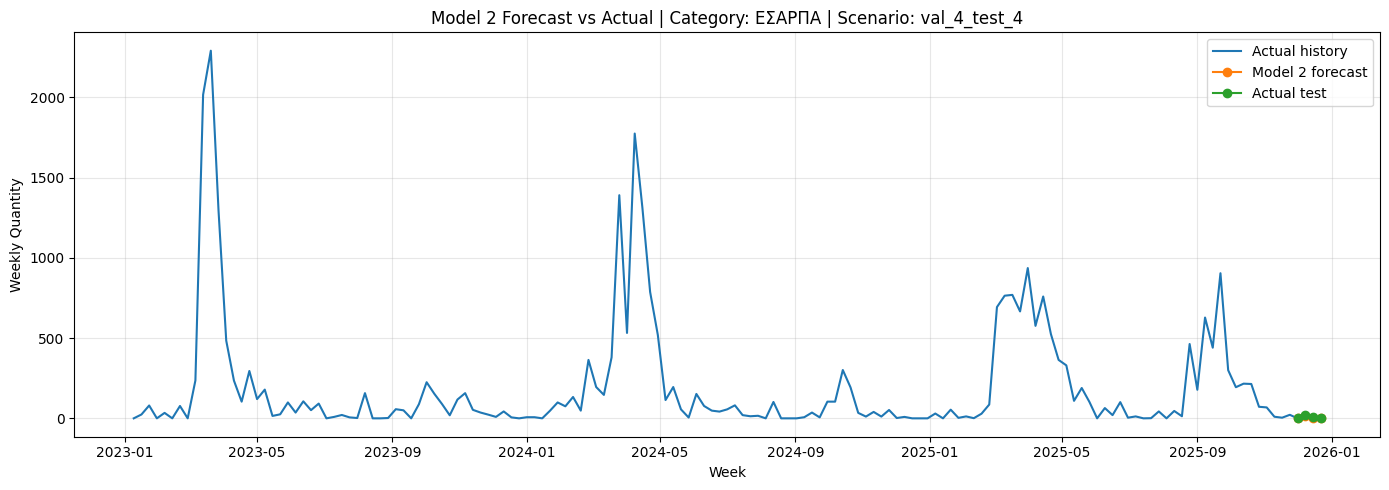

In [71]:
if not validation_summary.empty:
    plt.figure(figsize=(14, 6))
    for label in validation_summary[["model_family", "target_transformation"]].drop_duplicates().itertuples(index=False):
        family = label.model_family
        transformation = label.target_transformation
        temp = validation_summary[
            (validation_summary["model_family"] == family) &
            (validation_summary["target_transformation"] == transformation)
        ]
        plt.plot(temp["scenario_id"], temp["mean_MASE"], marker="o", label=f"{family}-{transformation}")
    plt.title("Model 2 Validation MASE by Model Family, Target Transformation, and Split Scenario")
    plt.xlabel("Split Scenario")
    plt.ylabel("Mean Validation MASE")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_validation_mase_by_family.png", dpi=150)
    plt.show()

if not test_results_df.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(test_results_df["scenario_id"], test_results_df["MASE"], marker="o")
    plt.title("Model 2 Test MASE by Split Scenario")
    plt.xlabel("Split Scenario")
    plt.ylabel("Test MASE")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_test_mase_by_scenario.png", dpi=150)
    plt.show()

if not model_comparison.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(model_comparison["scenario_id"], model_comparison["model_1_MASE"], marker="o", label="Model 1 Statistical Benchmark")
    plt.plot(model_comparison["scenario_id"], model_comparison["model_2_MASE"], marker="o", label="Model 2 Tree-Based ML")
    plt.title("Model 1 vs Model 2 Test MASE Comparison")
    plt.xlabel("Split Scenario")
    plt.ylabel("Mean Test MASE")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_1_vs_model_2_mase.png", dpi=150)
    plt.show()

if not forecasts_df.empty:
    plot_scenario = forecasts_df["scenario_id"].iloc[0]
    total_by_category = (
        category_df
        .groupby(CATEGORY_COL, as_index=False)
        .agg(total_quantity=(TARGET_COL, "sum"))
        .sort_values("total_quantity", ascending=False)
    )
    plot_categories = total_by_category.head(6)[CATEGORY_COL].tolist()

    for category in plot_categories:
        history = category_df[category_df[CATEGORY_COL] == category].copy()
        forecast_plot = forecasts_df[
            (forecasts_df[CATEGORY_COL] == category) &
            (forecasts_df["scenario_id"] == plot_scenario)
        ].copy()

        if forecast_plot.empty:
            continue

        plt.figure(figsize=(14, 5))
        plt.plot(history[DATE_COL], history[TARGET_COL], label="Actual history")
        plt.plot(forecast_plot[DATE_COL], forecast_plot["y_pred"], marker="o", label="Model 2 forecast")
        plt.plot(forecast_plot[DATE_COL], forecast_plot["y_true"], marker="o", label="Actual test")
        plt.title(f"Model 2 Forecast vs Actual | Category: {category} | Scenario: {plot_scenario}")
        plt.xlabel("Week")
        plt.ylabel("Weekly Quantity")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_category_name = str(category).replace("/", "_").replace(" ", "_")
        plt.savefig(MODEL_2_OUTPUT_DIR / f"plot_model_2_forecast_vs_actual_{safe_category_name}_{plot_scenario}.png", dpi=150)
        plt.show()

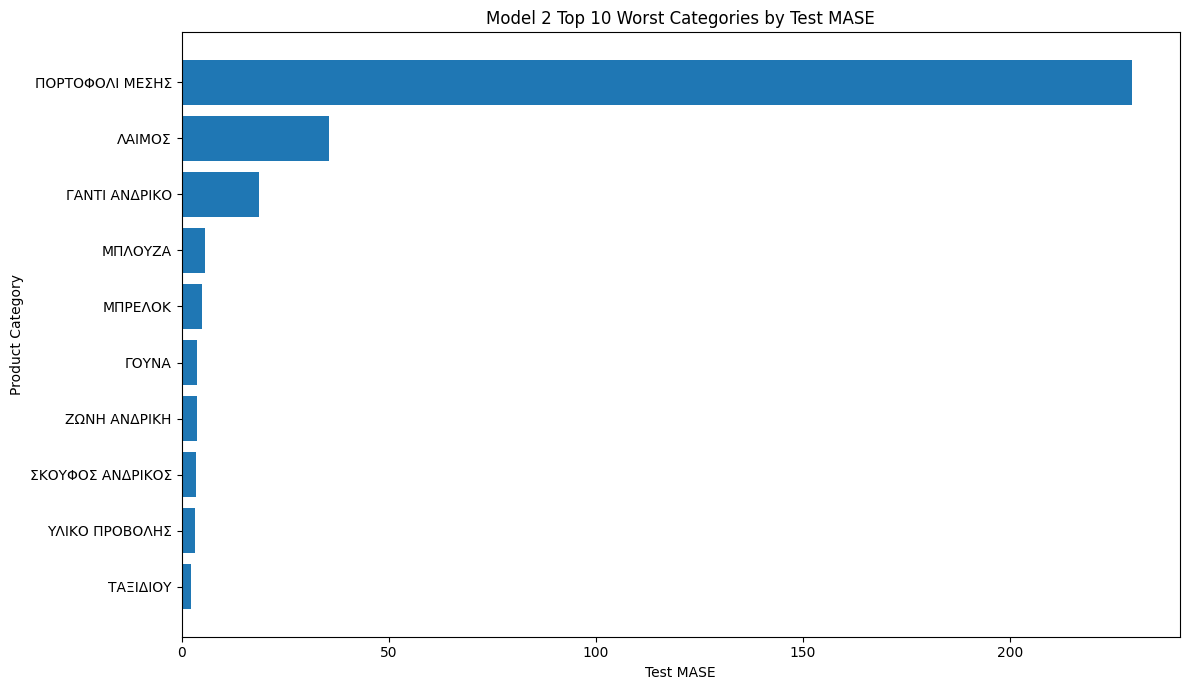

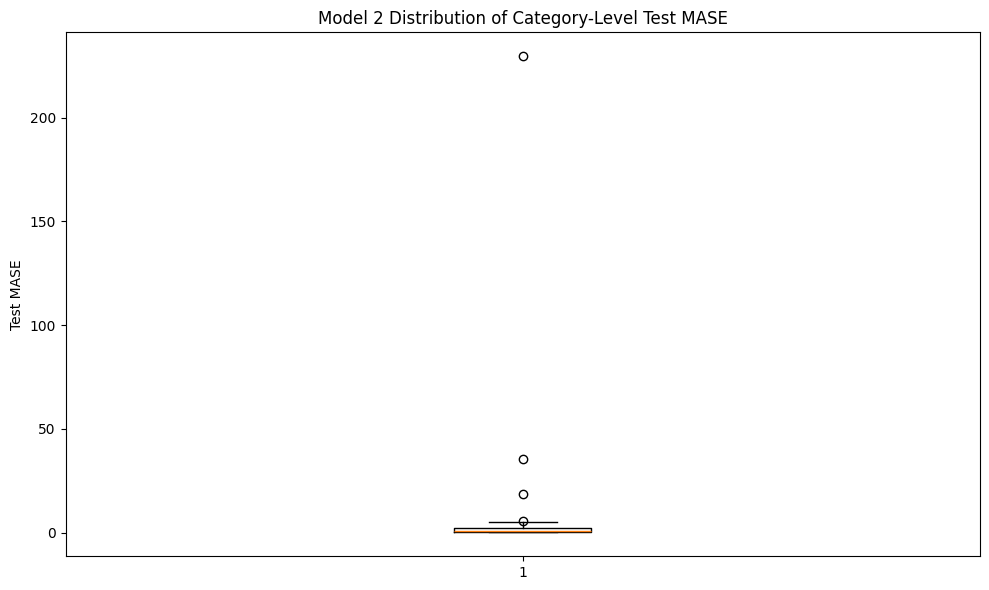

In [72]:
if not forecasts_df.empty:
    category_metric_rows = []
    for category in forecasts_df[CATEGORY_COL].unique():
        cat_forecasts = forecasts_df[forecasts_df[CATEGORY_COL] == category]
        cat_history = category_df[category_df[CATEGORY_COL] == category][TARGET_COL].values
        cat_metrics = evaluate_forecast(
            y_true=cat_forecasts["y_true"].values,
            y_pred=cat_forecasts["y_pred"].values,
            y_train=cat_history,
            seasonality=1
        )
        category_metric_rows.append({CATEGORY_COL: category, **cat_metrics})

    category_metrics_df = pd.DataFrame(category_metric_rows)
    category_metrics_file = MODEL_2_OUTPUT_DIR / "model_2_category_error_summary.csv"
    category_metrics_df.to_csv(category_metrics_file, index=False, encoding="utf-8-sig")

    worst_categories = category_metrics_df.sort_values("MASE", ascending=False).head(10)
    plt.figure(figsize=(12, 7))
    plt.barh(worst_categories[CATEGORY_COL].astype(str), worst_categories["MASE"])
    plt.title("Model 2 Top 10 Worst Categories by Test MASE")
    plt.xlabel("Test MASE")
    plt.ylabel("Product Category")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_worst_categories_mase.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.boxplot(category_metrics_df["MASE"].dropna())
    plt.title("Model 2 Distribution of Category-Level Test MASE")
    plt.ylabel("Test MASE")
    plt.tight_layout()
    plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_category_mase_distribution.png", dpi=150)
    plt.show()


Running SHAP explainability for scenario: val_4_test_4
Selected configuration: lgbm_002_log1p
SHAP sample size: (500, 40)

Top SHAP features:
                    feature  mean_abs_shap
9                     lag_1       0.454154
16           rolling_mean_4       0.419950
3          from_china_share       0.178420
10                    lag_2       0.129158
1      avg_gross_margin_pct       0.127759
24                 week_sin       0.109151
19            rolling_std_8       0.096908
32  recent_positive_ratio_4       0.086049
15                   lag_52       0.085411
18           rolling_mean_8       0.084621
39         category_encoded       0.077339
25                 week_cos       0.065651
0            avg_unit_price       0.061574
33      recent_zero_ratio_4       0.052262
35      recent_zero_ratio_8       0.050196
6                     month       0.041894
34  recent_positive_ratio_8       0.039711
38              zero_streak       0.036608
8              week_of_year       0.0364

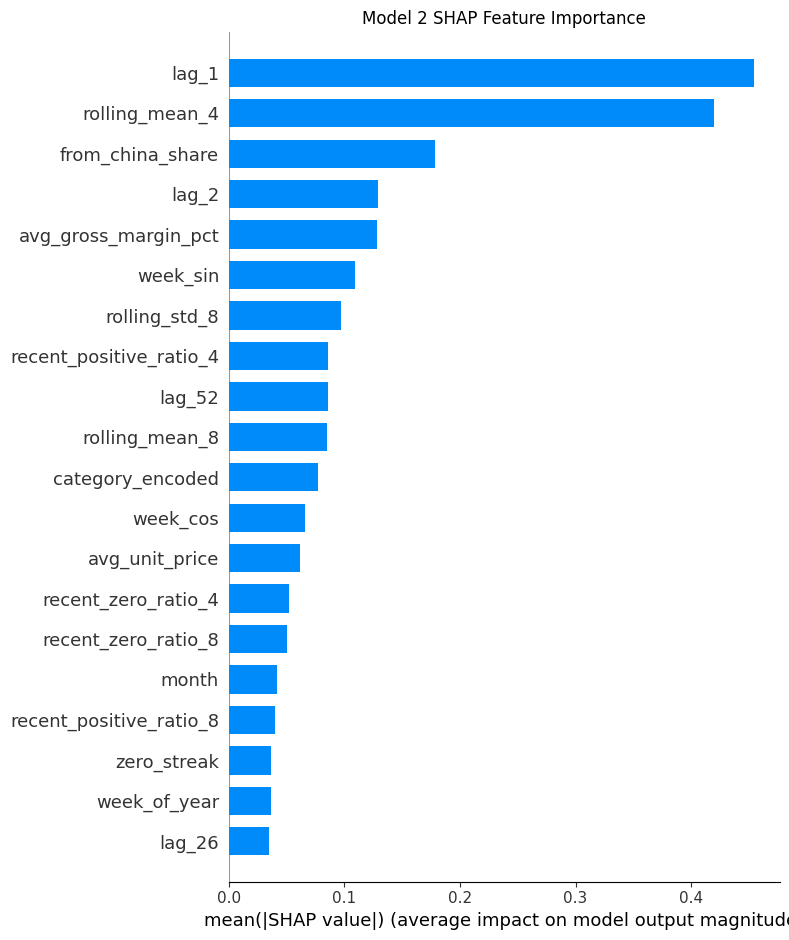

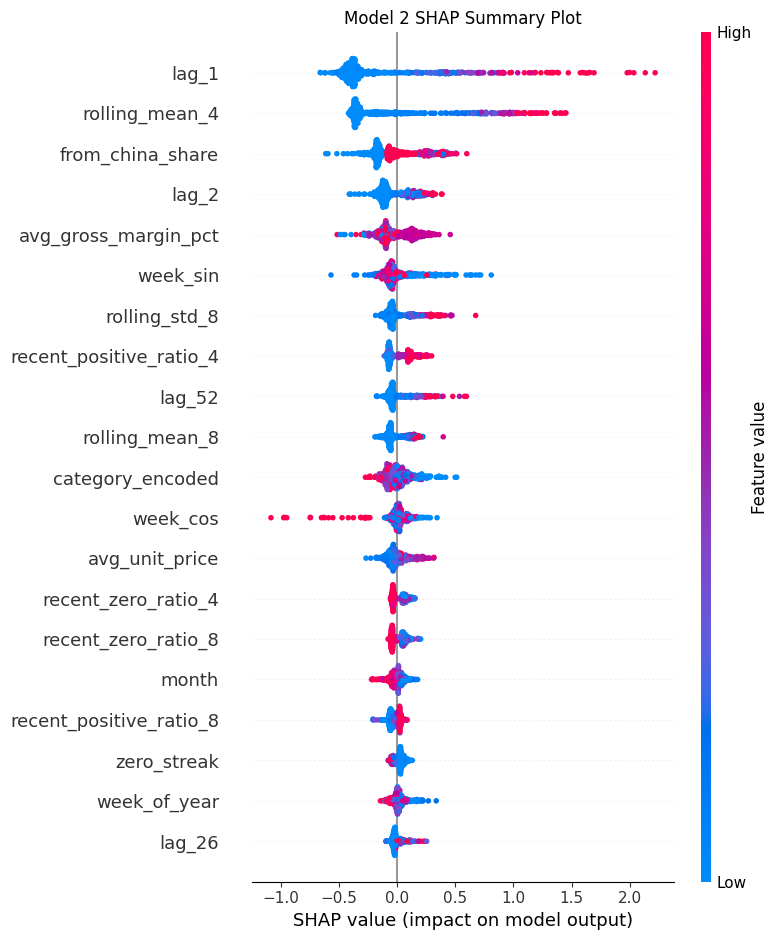

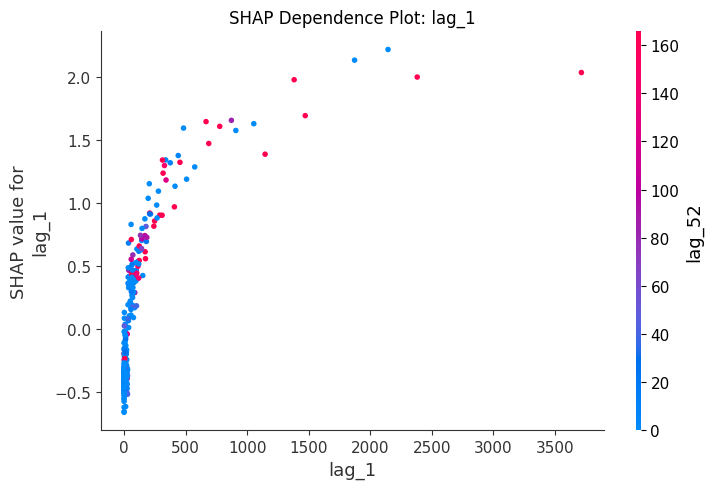

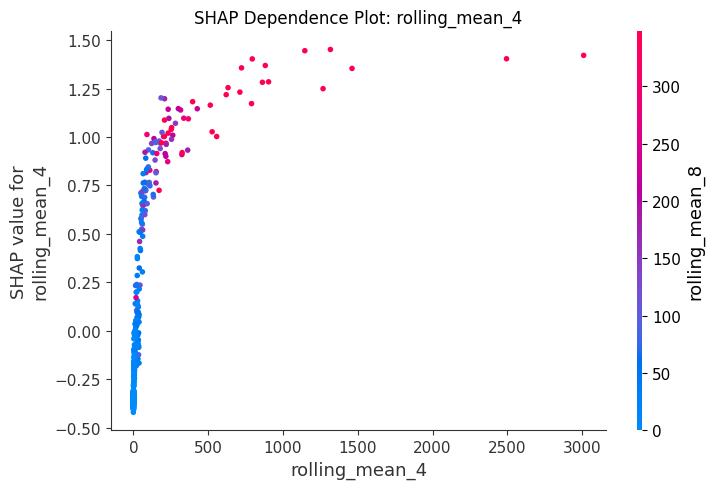

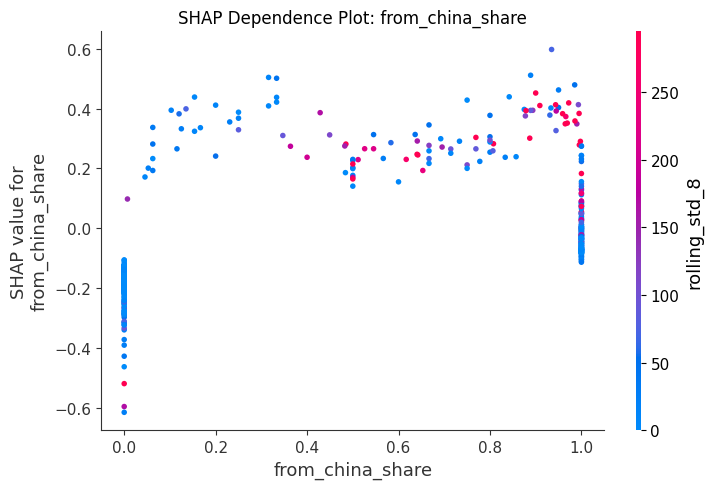

In [73]:
if SHAP_AVAILABLE and trained_selected_models and not test_results_df.empty:
    best_scenario_row = test_results_df.sort_values(["MASE", "RMSE", "MAE"]).iloc[0]
    best_scenario_id = best_scenario_row["scenario_id"]
    best_model_bundle = trained_selected_models[best_scenario_id]
    best_model = best_model_bundle["model"]
    best_config = best_model_bundle["config"]
    best_split_column = f"split_{best_scenario_id}"

    shap_background_df = category_df[category_df[best_split_column].isin(["train", "validation"])].copy()

    shap_sample_size = min(500, shap_background_df.shape[0])
    shap_background_sample = shap_background_df.sample(
        n=shap_sample_size,
        random_state=RANDOM_STATE
    )

    X_shap = shap_background_sample[feature_columns].astype(float)

    print("\nRunning SHAP explainability for scenario:", best_scenario_id)
    print("Selected configuration:", best_config["config_id"])
    print("SHAP sample size:", X_shap.shape)

    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)

        shap_importance = pd.DataFrame({
            "feature": feature_columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        }).sort_values("mean_abs_shap", ascending=False)

        shap_importance_file = MODEL_2_OUTPUT_DIR / "model_2_shap_feature_importance.csv"
        shap_importance.to_csv(shap_importance_file, index=False, encoding="utf-8-sig")

        print("\nTop SHAP features:")
        print(shap_importance.head(20))

        shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
        plt.title("Model 2 SHAP Feature Importance")
        plt.tight_layout()
        plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_shap_bar.png", dpi=150, bbox_inches="tight")
        plt.show()

        shap.summary_plot(shap_values, X_shap, show=False)
        plt.title("Model 2 SHAP Summary Plot")
        plt.tight_layout()
        plt.savefig(MODEL_2_OUTPUT_DIR / "plot_model_2_shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()

        top_features = shap_importance.head(3)["feature"].tolist()
        for feature in top_features:
            shap.dependence_plot(feature, shap_values, X_shap, show=False)
            plt.title(f"SHAP Dependence Plot: {feature}")
            plt.tight_layout()
            safe_feature_name = feature.replace("/", "_").replace(" ", "_")
            plt.savefig(MODEL_2_OUTPUT_DIR / f"plot_model_2_shap_dependence_{safe_feature_name}.png", dpi=150, bbox_inches="tight")
            plt.show()

    except Exception as e:
        print("SHAP analysis failed:", e)
else:
    print("SHAP analysis skipped because SHAP is unavailable or no selected models were trained.")

In [74]:
files_to_check = [
    VALIDATION_RESULTS_FILE,
    TEST_RESULTS_FILE,
    BEST_CONFIG_FILE,
    FORECASTS_FILE,
    validation_summary_file,
    test_summary_file,
    selected_config_counts_file,
    EXPERIMENT_LOG_FILE,
    feature_list_file
]

if MODEL_COMPARISON_FILE.exists():
    files_to_check.append(MODEL_COMPARISON_FILE)

print("\nOutput file verification:")
for file_path in files_to_check:
    if not file_path.exists():
        raise FileNotFoundError(f"Expected file not created: {file_path}")
    file_size_mb = file_path.stat().st_size / (1024 ** 2)
    modified_time = datetime.fromtimestamp(file_path.stat().st_mtime)
    print(f"{file_path.name} | size: {file_size_mb:.3f} MB | modified: {modified_time}")

print("\nModel 2 Final No-Leakage Tree-Based Forecasting notebook completed successfully.")


Output file verification:
model_2_validation_results.csv | size: 0.189 MB | modified: 2026-06-07 21:39:00
model_2_test_results.csv | size: 0.004 MB | modified: 2026-06-07 21:39:00
model_2_best_configurations.csv | size: 0.004 MB | modified: 2026-06-07 21:39:00
model_2_all_forecasts.csv | size: 0.304 MB | modified: 2026-06-07 21:39:00
model_2_validation_summary_by_family.csv | size: 0.004 MB | modified: 2026-06-07 21:39:00
model_2_test_summary_selected_models.csv | size: 0.000 MB | modified: 2026-06-07 21:39:00
model_2_selected_config_counts.csv | size: 0.000 MB | modified: 2026-06-07 21:39:00
model_2_experiment_log.json | size: 0.025 MB | modified: 2026-06-07 21:10:41
model_2_feature_columns.csv | size: 0.001 MB | modified: 2026-06-07 21:10:48
model_1_vs_model_2_comparison.csv | size: 0.002 MB | modified: 2026-06-07 21:39:01

Model 2 Final No-Leakage Tree-Based Forecasting notebook completed successfully.
